<a href="https://colab.research.google.com/github/Juli-Kareva/Fraud-detection-MDS/blob/main/Prototypical_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Фаза 3 — Prototypical Networks для детекции фрода

**Цель:** обучить мета-модель на Base.csv (train), затем оценить адаптацию на Variants I–VI.  
**Архитектура:**
- Meta-train: сэмплируем мини-эпизоды (2-way K-shot) из `train_clean.csv`
- Meta-test: один эпизод = один Variant целиком (support set → прототипы → оценка на query)

**Зависимости от предыдущих ноутбуков:** `train_clean.csv`, `test_clean.csv`, `oot_clean.csv`, `Variant_I_clean.csv` … `Variant_VI_clean.csv`, `scaler_baseline.pkl`

## 0. Установка зависимостей

In [1]:
!pip install -q tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import pickle
import random
import os
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_recall_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Воспроизводимость
SEED = 1208
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {DEVICE}')

Устройство: cuda


## Загрузка данных

In [2]:
FEATURES = [
    'name_email_similarity', 'session_length_in_minutes', 'zip_count_4w',
    'velocity_6h', 'credit_risk_score', 'zip_count_4w_clean',
    'current_address_months_count_clean', 'date_of_birth_distinct_emails_4w',
    'bank_branch_count_8w_clean', 'bank_months_count', 'income',
    'proposed_credit_limit', 'customer_age', 'device_os_windows',
    'email_is_free', 'phone_home_valid', 'keep_alive_session',
    'phone_mobile_valid', 'housing_status_BC', 'payment_type_AB',
    'payment_type_AC', 'housing_status_BB', 'foreign_request',
    'payment_type_AD', 'has_other_cards', 'prev_address_months_count_clean',
    'employment_status_CB', 'employment_status_CC', 'device_os_other',
    'device_os_macintosh', 'housing_status_BE', 'housing_status_BD',
    'source_TELEAPP', 'employment_status_CD', 'device_os_x11'
]
TARGET = 'fraud_bool'
INPUT_DIM = len(FEATURES)  # 35

DATA_DIR = '/content/'

train_df = pd.read_csv(os.path.join(DATA_DIR, 'df_train.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'df_test.csv'))
oot_df   = pd.read_csv(os.path.join(DATA_DIR, 'df_oot.csv'))

VARIANT_NAMES = ['I', 'II', 'III', 'IV', 'V']

variants = {}
for v in VARIANT_NAMES:
    variants[v] = pd.read_csv(os.path.join(DATA_DIR, f'{DATA_DIR}Variant {v}.csv'))

print(f'Train: {len(train_df):,} строк | фродов: {train_df[TARGET].mean():.2%}')
print(f'Test:  {len(test_df):,} строк  | фродов: {test_df[TARGET].mean():.2%}')
print(f'OOT:   {len(oot_df):,} строк  | фродов: {oot_df[TARGET].mean():.2%}')
for name, df in variants.items():
    print(f'Variant {name}: {len(df):,} строк | фродов: {df[TARGET].mean():.2%}')

Train: 675,666 строк | фродов: 1.00%
Test:  119,323 строк  | фродов: 1.18%
OOT:   205,011 строк  | фродов: 1.40%
Variant I: 1,000,000 строк | фродов: 1.10%
Variant II: 1,000,000 строк | фродов: 1.10%
Variant III: 1,000,000 строк | фродов: 1.10%
Variant IV: 1,000,000 строк | фродов: 1.10%
Variant V: 1,000,000 строк | фродов: 1.10%


In [3]:
import joblib

scaler = joblib.load(os.path.join(DATA_DIR, 'scaler_baseline.pkl'))

def scale(df, features=FEATURES):
    """Применяет baseline-скейлер к DataFrame, возвращает numpy array."""
    return scaler.transform(df[features].values)

X_train = scale(train_df)
y_train = train_df[TARGET].values

X_test  = scale(test_df)
y_test  = test_df[TARGET].values

X_oot   = scale(oot_df)
y_oot   = oot_df[TARGET].values

X_variants = {name: scale(df) for name, df in variants.items()}
y_variants = {name: df[TARGET].values for name, df in variants.items()}

print(f'X_train shape: {X_train.shape}')

X_train shape: (675666, 35)


## Проверка и дочистка данных

In [4]:
nan_cols = train_df[FEATURES].isnull().sum()
nan_cols = nan_cols[nan_cols > 0].sort_values(ascending=False)
print('Признаки с NaN в train_clean:')
print(nan_cols)

Признаки с NaN в train_clean:
prev_address_months_count_clean       469907
current_address_months_count_clean      2827
velocity_6h                                9
dtype: int64


In [5]:
FILL_MINUS1 = ['prev_address_months_count_clean']
FILL_MEDIAN  = ['current_address_months_count_clean', 'velocity_6h']

# Считаем медианы по train
medians = train_df[FILL_MEDIAN].median()
print('Медианы по train:')
print(medians)

def fix_nan(df):
    df = df.copy()
    for col in FILL_MINUS1:
        if col in df.columns:
            df[col] = df[col].fillna(-1)
    for col in FILL_MEDIAN:
        if col in df.columns:
            df[col] = df[col].fillna(medians[col])
    return df

train_df = fix_nan(train_df)
test_df  = fix_nan(test_df)
oot_df   = fix_nan(oot_df)
variants = {name: fix_nan(df) for name, df in variants.items()}

# Проверка
remaining = train_df[FEATURES].isnull().sum().sum()
print(f'\nNaN в train после дочистки: {remaining}')

X_train    = scaler.transform(train_df[FEATURES].values)
X_test     = scaler.transform(test_df[FEATURES].values)
X_oot      = scaler.transform(oot_df[FEATURES].values)
X_variants = {name: scaler.transform(df[FEATURES].values) for name, df in variants.items()}

y_train    = train_df[TARGET].values
y_test     = test_df[TARGET].values
y_oot      = oot_df[TARGET].values
y_variants = {name: df[TARGET].values for name, df in variants.items()}

print('NaN в X_train:', np.isnan(X_train).any())

Медианы по train:
current_address_months_count_clean      48.00000
velocity_6h                           6274.67205
dtype: float64

NaN в train после дочистки: 0
NaN в X_train: False


## Episode Sampler

Два режима:
- **meta-train**: случайные мини-эпизоды из `train_clean` (много эпизодов, обучение энкодера)
- **meta-test**: один эпизод = один Variant целиком (6 эпизодов для оценки)

In [6]:
class EpisodeSampler:
    """
    Сэмплер эпизодов для Prototypical Networks.

    Meta-train режим:
        Случайно сэмплирует N_WAY классов (здесь всегда 2: фрод/не-фрод),
        K_SHOT примеров в support, N_QUERY примеров в query.

    Meta-test режим:
        Фиксированный support (K примеров каждого класса),
        остаток — query set.
    """

    def __init__(self, X, y, k_shot=10, n_query=50, seed=42):
        """
        X      : np.array (N, D) — масштабированные признаки
        y      : np.array (N,)  — бинарные метки (0/1)
        k_shot : размер support set на класс
        n_query: размер query set на класс (только для meta-train)
        """
        self.X = X
        self.y = y
        self.k_shot  = k_shot
        self.n_query = n_query
        self.rng = np.random.default_rng(seed)

        # Индексы по классам
        self.idx_0 = np.where(y == 0)[0]  # не-фрод
        self.idx_1 = np.where(y == 1)[0]  # фрод

        print(f'EpisodeSampler: класс 0={len(self.idx_0):,}, класс 1={len(self.idx_1):,}')
        print(f'k_shot={k_shot}, n_query={n_query}')

    def sample_train_episode(self):
        """
        Возвращает один мини-эпизод для meta-train.
        Returns:
            support_x : Tensor (2*k_shot, D)
            support_y : Tensor (2*k_shot,)   — метки {0, 1}
            query_x   : Tensor (2*n_query, D)
            query_y   : Tensor (2*n_query,)
        """
        # Сэмплируем k_shot + n_query индексов из каждого класса
        s0 = self.rng.choice(self.idx_0, size=self.k_shot + self.n_query, replace=False)
        s1 = self.rng.choice(self.idx_1, size=self.k_shot + self.n_query, replace=False)

        sup_x = np.vstack([self.X[s0[:self.k_shot]], self.X[s1[:self.k_shot]]])
        sup_y = np.concatenate([np.zeros(self.k_shot), np.ones(self.k_shot)])

        qry_x = np.vstack([self.X[s0[self.k_shot:]], self.X[s1[self.k_shot:]]])
        qry_y = np.concatenate([np.zeros(self.n_query), np.ones(self.n_query)])

        return (
            torch.tensor(sup_x, dtype=torch.float32),
            torch.tensor(sup_y, dtype=torch.long),
            torch.tensor(qry_x, dtype=torch.float32),
            torch.tensor(qry_y, dtype=torch.long),
        )

    def make_test_episode(self, k_shot=None):
        """
        Формирует meta-test эпизод из ВСЕГО датасета.
        Support = k_shot примеров каждого класса (стратифицированно).
        Query  = все оставшиеся примеры.
        Returns:
            support_x, support_y, query_x, query_y  — Tensors
        """
        k = k_shot or self.k_shot

        sup_idx0 = self.rng.choice(self.idx_0, size=k, replace=False)
        sup_idx1 = self.rng.choice(self.idx_1, size=k, replace=False)

        sup_mask = np.zeros(len(self.y), dtype=bool)
        sup_mask[sup_idx0] = True
        sup_mask[sup_idx1] = True

        qry_mask = ~sup_mask

        sup_x = np.vstack([self.X[sup_idx0], self.X[sup_idx1]])
        sup_y = np.concatenate([np.zeros(k), np.ones(k)])

        qry_x = self.X[qry_mask]
        qry_y = self.y[qry_mask]

        return (
            torch.tensor(sup_x, dtype=torch.float32),
            torch.tensor(sup_y, dtype=torch.long),
            torch.tensor(qry_x, dtype=torch.float32),
            torch.tensor(qry_y, dtype=torch.long),
        )


# Инициализация сэмплера для meta-train
meta_train_sampler = EpisodeSampler(
    X_train, y_train,
    k_shot=10,    # 10 примеров каждого класса в support
    n_query=50    # 50 примеров каждого класса в query
)

# Проверка: один тестовый эпизод
sx, sy, qx, qy = meta_train_sampler.sample_train_episode()
print(f'\nТестовый эпизод:')
print(f'  Support: {sx.shape}, метки: {sy.tolist()[:5]}...')
print(f'  Query:   {qx.shape}, фродов в query: {qy.float().mean():.1%}')

EpisodeSampler: класс 0=668,926, класс 1=6,740
k_shot=10, n_query=50

Тестовый эпизод:
  Support: torch.Size([20, 35]), метки: [0, 0, 0, 0, 0]...
  Query:   torch.Size([100, 35]), фродов в query: 50.0%


## Архитектура энкодера

Два варианта для сравнения:
- **MLP-S** (shallow): 35 → 128 → 64
- **MLP-D** (deep): 35 → 256 → 128 → 64 → 32 + BatchNorm + Dropout

In [7]:
class EncoderMLP_S(nn.Module):
    """Мелкий энкодер: 35 → 128 → 64. Эмбеддинг размерности 64."""

    def __init__(self, input_dim=35, hidden_dim=128, embed_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embed_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class EncoderMLP_D(nn.Module):
    """Глубокий энкодер: 35 → 256 → 128 → 64 → 32. BatchNorm + Dropout."""

    def __init__(self, input_dim=35, embed_dim=32, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, embed_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


# Быстрая проверка формы
dummy = torch.randn(8, INPUT_DIM)
enc_s = EncoderMLP_S(INPUT_DIM)
enc_d = EncoderMLP_D(INPUT_DIM)
print(f'EncoderMLP_S выход: {enc_s(dummy).shape}')  # (8, 64)
print(f'EncoderMLP_D выход: {enc_d(dummy).shape}')  # (8, 32)

# Число параметров
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Параметры MLP-S: {count_params(enc_s):,}')
print(f'Параметры MLP-D: {count_params(enc_d):,}')

EncoderMLP_S выход: torch.Size([8, 64])
EncoderMLP_D выход: torch.Size([8, 32])
Параметры MLP-S: 12,864
Параметры MLP-D: 53,344


## Prototypical Networks — ядро модели

In [8]:
class PrototypicalNetwork(nn.Module):
    """
    Prototypical Networks (Snell et al., 2017) для бинарной классификации.

    Алгоритм:
        1. Кодируем support set → получаем эмбеддинги
        2. Усредняем эмбеддинги по классу → прототипы c_0, c_1
        3. Для каждого query-примера считаем евклидово расстояние до c_0 и c_1
        4. Softmax(-dist) → вероятности → cross-entropy loss
    """

    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder

    def compute_prototypes(self, support_x, support_y):
        """
        Вычисляет прототипы классов как среднее эмбеддингов.
        support_x : Tensor (2*k_shot, D)
        support_y : Tensor (2*k_shot,)  — 0 или 1
        Returns:
            prototypes : Tensor (2, embed_dim) — [proto_0, proto_1]
        """
        embs = self.encoder(support_x)          # (2*k_shot, E)
        proto_0 = embs[support_y == 0].mean(0)  # (E,)
        proto_1 = embs[support_y == 1].mean(0)  # (E,)
        return torch.stack([proto_0, proto_1])  # (2, E)

    def forward(self, support_x, support_y, query_x):
        """
        Returns:
            log_probs : Tensor (N_query, 2) — log-вероятности классов
            fraud_probs : Tensor (N_query,) — P(fraud) для метрик
        """
        prototypes = self.compute_prototypes(support_x, support_y)  # (2, E)
        query_embs = self.encoder(query_x)                           # (N_q, E)

        # Евклидово расстояние: (N_q, 2)
        # ||q - p||^2 = sum((q - p)^2)
        dists = torch.cdist(query_embs, prototypes, p=2)  # (N_q, 2)

        # Softmax(-dist) → вероятности
        log_probs = torch.log_softmax(-dists, dim=1)      # (N_q, 2)
        fraud_probs = torch.softmax(-dists, dim=1)[:, 1]  # P(fraud)

        return log_probs, fraud_probs


# Быстрая проверка прямого прохода
net_s = PrototypicalNetwork(EncoderMLP_S(INPUT_DIM)).to(DEVICE)
sx, sy, qx, qy = meta_train_sampler.sample_train_episode()
sx, sy, qx = sx.to(DEVICE), sy.to(DEVICE), qx.to(DEVICE)

with torch.no_grad():
    # 1. Проверяем входные данные
    print(f'sx содержит NaN: {torch.isnan(sx).any().item()}')
    print(f'sx содержит inf: {torch.isinf(sx).any().item()}')
    print(f'Классы в support: {sy.unique().tolist()}')

    # 2. Проверяем эмбеддинги
    embs = net_s.encoder(sx)
    print(f'\nЭмбеддинги NaN: {torch.isnan(embs).any().item()}')
    print(f'Эмбеддинги inf: {torch.isinf(embs).any().item()}')
    print(f'Эмбеддинги min/max: {embs.min().item():.4f} / {embs.max().item():.4f}')

    # 3. Проверяем прототипы
    protos = net_s.compute_prototypes(sx, sy)
    print(f'\nПрототипы:\n{protos}')
    print(f'Прототипы NaN: {torch.isnan(protos).any().item()}')

    # 4. Проверяем расстояния
    qembs = net_s.encoder(qx)
    dists = torch.cdist(qembs, protos, p=2)
    print(f'\nРасстояния NaN: {torch.isnan(dists).any().item()}')
    print(f'Расстояния min/max: {dists.min().item():.4f} / {dists.max().item():.4f}')

sx содержит NaN: False
sx содержит inf: False
Классы в support: [0, 1]

Эмбеддинги NaN: False
Эмбеддинги inf: False
Эмбеддинги min/max: 0.0000 / 0.8628

Прототипы:
tensor([[0.0941, 0.2315, 0.0404, 0.0595, 0.0823, 0.0000, 0.0015, 0.1572, 0.1155,
         0.0243, 0.0187, 0.0535, 0.1297, 0.0891, 0.0393, 0.0966, 0.1995, 0.0566,
         0.0290, 0.0739, 0.0659, 0.0422, 0.1895, 0.0996, 0.0445, 0.0196, 0.0918,
         0.1212, 0.1130, 0.0982, 0.1563, 0.0078, 0.0481, 0.0066, 0.0605, 0.0095,
         0.0575, 0.1470, 0.1055, 0.0039, 0.0000, 0.2449, 0.0862, 0.0546, 0.0645,
         0.2016, 0.1871, 0.1711, 0.0085, 0.2813, 0.1735, 0.1146, 0.0155, 0.0330,
         0.1348, 0.0295, 0.0271, 0.2009, 0.1088, 0.0591, 0.0397, 0.0080, 0.1340,
         0.0493],
        [0.2176, 0.1534, 0.0215, 0.0035, 0.1051, 0.0416, 0.0416, 0.0485, 0.1184,
         0.0000, 0.0908, 0.0717, 0.0517, 0.1508, 0.1055, 0.0148, 0.0794, 0.0324,
         0.0445, 0.0810, 0.0975, 0.0648, 0.1375, 0.1092, 0.1423, 0.0000, 0.0757,
        

## Цикл meta-train

In [9]:
def train_protonet(
    encoder_class,
    sampler,
    n_episodes=2000,
    lr=1e-3,
    device=DEVICE,
    log_every=200,
    encoder_kwargs=None,
):
    """
    Обучает Prototypical Network эпизодически.

    Args:
        encoder_class : класс энкодера (EncoderMLP_S или EncoderMLP_D)
        sampler       : EpisodeSampler с meta-train данными
        n_episodes    : количество эпизодов обучения
        lr            : learning rate (Adam)
        log_every     : частота логирования loss
        encoder_kwargs: доп. аргументы для энкодера

    Returns:
        model  : обученная PrototypicalNetwork
        losses : список значений loss
    """
    if encoder_kwargs is None:
        encoder_kwargs = {'input_dim': INPUT_DIM}
    else:
        encoder_kwargs = {'input_dim': INPUT_DIM, **encoder_kwargs}

    encoder = encoder_class(**encoder_kwargs)
    model   = PrototypicalNetwork(encoder).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.NLLLoss()

    losses = []
    model.train()

    for ep in tqdm(range(1, n_episodes + 1), desc='Meta-train'):
        sup_x, sup_y, qry_x, qry_y = sampler.sample_train_episode()
        sup_x = sup_x.to(device)
        sup_y = sup_y.to(device)
        qry_x = qry_x.to(device)
        qry_y = qry_y.to(device)

        optimizer.zero_grad()
        log_probs, _ = model(sup_x, sup_y, qry_x)
        loss = loss_fn(log_probs, qry_y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if ep % log_every == 0:
            avg = np.mean(losses[-log_every:])
            print(f'  Эпизод {ep:>5} / {n_episodes} | loss (avg {log_every}): {avg:.4f}')

    return model, losses


print('Функция обучения определена')

Функция обучения определена


In [10]:
#  Обучение модели MLP-S (shallow encoder)

model_s, losses_s = train_protonet(
    EncoderMLP_S,
    meta_train_sampler,
    n_episodes=2000,
    lr=1e-3,
)

# Сохраняем веса
torch.save(model_s.state_dict(), '/content/protonet_mlp_s.pt')
print('Сохранено: /content/protonet_mlp_s.pt')

Meta-train:  11%|█         | 215/2000 [00:01<00:07, 230.58it/s]

  Эпизод   200 / 2000 | loss (avg 200): 0.4949


Meta-train:  22%|██▏       | 444/2000 [00:02<00:06, 245.58it/s]

  Эпизод   400 / 2000 | loss (avg 200): 0.4582


Meta-train:  31%|███       | 624/2000 [00:02<00:05, 235.36it/s]

...

  Эпизод  1600 / 2000 | loss (avg 200): 0.4316


Meta-train:  92%|█████████▏| 1837/2000 [00:07<00:00, 301.29it/s]

  Эпизод  1800 / 2000 | loss (avg 200): 0.4295


Meta-train: 100%|██████████| 2000/2000 [00:07<00:00, 251.96it/s]

  Эпизод  2000 / 2000 | loss (avg 200): 0.4349
Сохранено: /content/protonet_mlp_s.pt


In [11]:
#  Обучение модели MLP-D (deep encoder)

model_d, losses_d = train_protonet(
    EncoderMLP_D,
    meta_train_sampler,
    n_episodes=2000,
    lr=5e-4,  # чуть меньше lr для глубокой сети
)

torch.save(model_d.state_dict(), '/content/protonet_mlp_d.pt')
print('Сохранено: /content/protonet_mlp_d.pt')

Meta-train:  11%|█         | 221/2000 [00:01<00:09, 179.62it/s]

  Эпизод   200 / 2000 | loss (avg 200): 0.5245


Meta-train:  22%|██▏       | 431/2000 [00:02<00:08, 184.59it/s]

  Эпизод   400 / 2000 | loss (avg 200): 0.4728


Meta-train:  31%|███▏      | 628/2000 [00:03<00:07, 191.15it/s]

...

  Эпизод  1600 / 2000 | loss (avg 200): 0.4397


Meta-train:  91%|█████████ | 1823/2000 [00:09<00:00, 189.29it/s]

  Эпизод  1800 / 2000 | loss (avg 200): 0.4372


Meta-train: 100%|██████████| 2000/2000 [00:11<00:00, 180.76it/s]

  Эпизод  2000 / 2000 | loss (avg 200): 0.4405
Сохранено: /content/protonet_mlp_d.pt


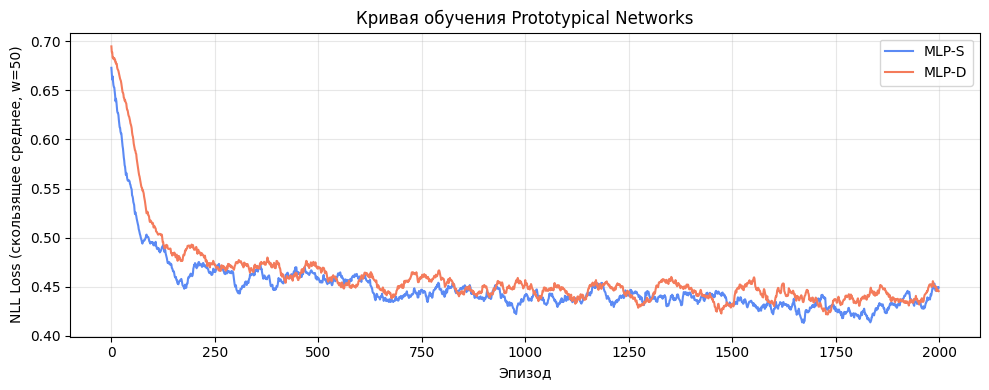

График сохранён: /content/protonet_loss_curve.png


In [12]:

def smooth(x, w=50):
    return pd.Series(x).rolling(w, min_periods=1).mean().values

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(smooth(losses_s), label='MLP-S', color='#5B8AF4')
ax.plot(smooth(losses_d), label='MLP-D', color='#F47B5B')
ax.set_xlabel('Эпизод')
ax.set_ylabel('NLL Loss (скользящее среднее, w=50)')
ax.set_title('Кривая обучения Prototypical Networks')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/protonet_loss_curve.png', dpi=150)
plt.show()
print('График сохранён: /content/protonet_loss_curve.png')

## Meta-test: оценка на Variants I–VI

In [13]:
def find_best_threshold_f1(y_true, y_proba):
    """
    Ищет порог, максимизирующий F1-score по PR-кривой.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx] if best_idx < len(thresholds) else 0.5


def evaluate_on_variant(
    model,
    X_var,
    y_var,
    k_shot=10,
    device=DEVICE,
    variant_name='',
):
    """
    Оценивает ProtoNet на одном Variant.
    Support set = k_shot примеров каждого класса (стратифицированно).
    Query set   = все оставшиеся примеры.

    Returns: dict с метриками
    """
    sampler = EpisodeSampler(X_var, y_var, k_shot=k_shot, n_query=0)
    sup_x, sup_y, qry_x, qry_y = sampler.make_test_episode(k_shot=k_shot)

    sup_x = sup_x.to(device)
    sup_y = sup_y.to(device)
    qry_x = qry_x.to(device)

    model.eval()
    with torch.no_grad():
        _, fraud_probs = model(sup_x, sup_y, qry_x)

    y_true  = qry_y.numpy()
    y_proba = fraud_probs.cpu().numpy()

    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc  = average_precision_score(y_true, y_proba)

    thr = find_best_threshold_f1(y_true, y_proba)
    y_pred = (y_proba >= thr).astype(int)
    f1 = f1_score(y_true, y_pred)

    return {
        'variant': variant_name,
        'roc_auc': round(roc_auc, 4),
        'pr_auc':  round(pr_auc, 4),
        'f1':      round(f1, 4),
        'threshold': round(thr, 4),
        'n_query': len(y_true),
        'fraud_rate': round(y_true.mean(), 4),
    }


print('Функция оценки определена.')

Функция оценки определена.


In [14]:
#  Оценка на Test и OOT (стандартный режим — без few-shot адаптации)
#  Используем прототипы из Train, query = Test / OOT

def evaluate_standard(model, X_sup, y_sup, X_qry, y_qry, split_name='', device=DEVICE):
    """
    Вычисляет прототипы на всём X_sup, затем оценивает на X_qry.
    Используется для Test и OOT (без few-shot ограничения).
    """
    # Для прототипов берём случайную выборку из train
    # (можно весь train, но для скорости — 500 примеров каждого класса)
    rng = np.random.default_rng(SEED)
    idx0 = rng.choice(np.where(y_sup == 0)[0], size=min(500, (y_sup==0).sum()), replace=False)
    idx1 = rng.choice(np.where(y_sup == 1)[0], size=min(500, (y_sup==1).sum()), replace=False)
    sup_idx = np.concatenate([idx0, idx1])

    sup_x = torch.tensor(X_sup[sup_idx], dtype=torch.float32).to(device)
    sup_y = torch.tensor(y_sup[sup_idx], dtype=torch.long).to(device)
    qry_x = torch.tensor(X_qry, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        _, fraud_probs = model(sup_x, sup_y, qry_x)

    y_true  = y_qry
    y_proba = fraud_probs.cpu().numpy()

    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc  = average_precision_score(y_true, y_proba)
    thr = find_best_threshold_f1(y_true, y_proba)
    f1 = f1_score(y_true, (y_proba >= thr).astype(int))

    return {
        'split':   split_name,
        'roc_auc': round(roc_auc, 4),
        'pr_auc':  round(pr_auc, 4),
        'f1':      round(f1, 4),
    }


results_std_s = []
results_std_d = []

for split_name, X_q, y_q in [('Test', X_test, y_test), ('OOT', X_oot, y_oot)]:
    res_s = evaluate_standard(model_s, X_train, y_train, X_q, y_q, split_name)
    res_d = evaluate_standard(model_d, X_train, y_train, X_q, y_q, split_name)
    results_std_s.append(res_s)
    results_std_d.append(res_d)
    print(f'{split_name} | MLP-S → ROC-AUC={res_s["roc_auc"]}, PR-AUC={res_s["pr_auc"]}, F1={res_s["f1"]}')
    print(f'{split_name} | MLP-D → ROC-AUC={res_d["roc_auc"]}, PR-AUC={res_d["pr_auc"]}, F1={res_d["f1"]}')

Test | MLP-S → ROC-AUC=0.8726, PR-AUC=0.1325, F1=0.2283
Test | MLP-D → ROC-AUC=0.876, PR-AUC=0.1116, F1=0.2283
OOT | MLP-S → ROC-AUC=0.8758, PR-AUC=0.1535, F1=0.237
OOT | MLP-D → ROC-AUC=0.8782, PR-AUC=0.1242, F1=0.238


In [16]:
#  Оценка на Variants I–VI (few-shot режим: k_shot=10)
#  Для каждого Variant: support = 10 примеров каждого класса,
#  query = всё остальное

K_SHOT_EVAL = 10  # можно поменять на 5 для сравнения

results_var_s = []
results_var_d = []

for name in ['I', 'II', 'III', 'IV', 'V']:
    res_s = evaluate_on_variant(model_s, X_variants[name], y_variants[name],
                                k_shot=K_SHOT_EVAL, variant_name=name)
    res_d = evaluate_on_variant(model_d, X_variants[name], y_variants[name],
                                k_shot=K_SHOT_EVAL, variant_name=name)
    results_var_s.append(res_s)
    results_var_d.append(res_d)
    print(f'Variant {name} | MLP-S → ROC-AUC={res_s["roc_auc"]}, PR-AUC={res_s["pr_auc"]}, F1={res_s["f1"]}')
    print(f'Variant {name} | MLP-D → ROC-AUC={res_d["roc_auc"]}, PR-AUC={res_d["pr_auc"]}, F1={res_d["f1"]}')
    print()

EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=10, n_query=0
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=10, n_query=0
Variant I | MLP-S → ROC-AUC=0.859, PR-AUC=0.1022, F1=0.178
Variant I | MLP-D → ROC-AUC=0.8583, PR-AUC=0.0874, F1=0.1822

EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=10, n_query=0
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=10, n_query=0
Variant II | MLP-S → ROC-AUC=0.8808, PR-AUC=0.1245, F1=0.2042
Variant II | MLP-D → ROC-AUC=0.8809, PR-AUC=0.0926, F1=0.2006

EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=10, n_query=0
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=10, n_query=0
Variant III | MLP-S → ROC-AUC=0.8534, PR-AUC=0.0905, F1=0.1676
Variant III | MLP-D → ROC-AUC=0.8547, PR-AUC=0.0784, F1=0.1682

EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=10, n_query=0
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=10, n_query=0
Variant IV | MLP-S → ROC-AUC=0.8781, PR-AUC=0.1161, F1=0.1971
Variant IV | 

## Итоговая таблица: ProtoNet vs LightGBM baseline

In [17]:

lgbm_metrics = {
    'Test':        {'roc_auc': 0.8863, 'pr_auc': 0.1723, 'f1': 0.2597},
    'OOT':         {'roc_auc': 0.8857, 'pr_auc': 0.1792, 'f1': 0.2549},
    'Variant_I':   {'roc_auc': 0.8718, 'pr_auc': 0.1300, 'f1': 0.2026},
    'Variant_II':  {'roc_auc': 0.8905, 'pr_auc': 0.1501, 'f1': 0.2238},
    'Variant_III': {'roc_auc': 0.8660, 'pr_auc': 0.1177, 'f1': 0.1893},
    'Variant_IV':  {'roc_auc': 0.8886, 'pr_auc': 0.1483, 'f1': 0.2208},
    'Variant_V':   {'roc_auc': 0.8689, 'pr_auc': 0.1175, 'f1': 0.1912}
}
logreg_metrics = {
    'Test':       {'ROC-AUC': 0.8462,'PR-AUC': 0.0872,'F1 (opt)': 0.0660},
    'OOT':        {'ROC-AUC': 0.8499, 'PR-AUC': 0.0997, 'F1 (opt)': 0.0774},
    'Variant I':  {'ROC-AUC': 0.8240, 'PR-AUC': 0.0644, 'F1 (opt)': 0.0581},
    'Variant II': {'ROC-AUC': 0.8539, 'PR-AUC': 0.0820, 'F1 (opt)': 0.0488},
    'Variant III':{'ROC-AUC': 0.8201, 'PR-AUC': 0.0614, 'F1 (opt)': 0.0468},
    'Variant IV': {'ROC-AUC': 0.8503, 'PR-AUC': 0.0797, 'F1 (opt)': 0.0490},
    'Variant V':  {'ROC-AUC': 0.8238, 'PR-AUC': 0.0653, 'F1 (opt)': 0.0470}
}

# --- Формируем сводную таблицу ---
rows = []

# ProtoNet MLP-S: Test/OOT
for r in results_std_s:
    rows.append({'split': r['split'], 'model': 'ProtoNet-S', **{k: r[k] for k in ['roc_auc', 'pr_auc', 'f1']}})
# ProtoNet MLP-D: Test/OOT
for r in results_std_d:
    rows.append({'split': r['split'], 'model': 'ProtoNet-D', **{k: r[k] for k in ['roc_auc', 'pr_auc', 'f1']}})

# ProtoNet MLP-S: Variants
for r in results_var_s:
    rows.append({'split': f'Variant_{r["variant"]}', 'model': 'ProtoNet-S',
                 'roc_auc': r['roc_auc'], 'pr_auc': r['pr_auc'], 'f1': r['f1']})
# ProtoNet MLP-D: Variants
for r in results_var_d:
    rows.append({'split': f'Variant_{r["variant"]}', 'model': 'ProtoNet-D',
                 'roc_auc': r['roc_auc'], 'pr_auc': r['pr_auc'], 'f1': r['f1']})

# LightGBM и LogReg baseline
for split, metrics in lgbm_metrics.items():
    rows.append({'split': split, 'model': 'LightGBM', **metrics})
for split, metrics in logreg_metrics.items():
    rows.append({'split': split, 'model': 'LogReg', **metrics})

results_df = pd.DataFrame(rows)
pivot = results_df.pivot_table(
    index='split',
    columns='model',
    values=['roc_auc', 'pr_auc', 'f1'],
    aggfunc='first'
).round(4)

print('=== Сводная таблица метрик ===')
print(pivot.to_string())

# Сохраняем в CSV
results_df.to_csv('/content/results_protonet_vs_baseline.csv', index=False)
pivot.to_csv('/content/results_protonet_pivot.csv')
print('\nСохранено: results_protonet_vs_baseline.csv, results_protonet_pivot.csv')

=== Сводная таблица метрик ===
                  f1                         pr_auc                        roc_auc                      
model       LightGBM ProtoNet-D ProtoNet-S LightGBM ProtoNet-D ProtoNet-S LightGBM ProtoNet-D ProtoNet-S
split                                                                                                   
OOT           0.2549     0.2380     0.2370   0.1792     0.1242     0.1535   0.8857     0.8782     0.8758
Test          0.2597     0.2283     0.2283   0.1723     0.1116     0.1325   0.8863     0.8760     0.8726
Variant_I     0.2026     0.1822     0.1780   0.1300     0.0874     0.1022   0.8718     0.8583     0.8590
Variant_II    0.2238     0.2006     0.2042   0.1501     0.0926     0.1245   0.8905     0.8809     0.8808
Variant_III   0.1893     0.1682     0.1676   0.1177     0.0784     0.0905   0.8660     0.8547     0.8534
Variant_IV    0.2208     0.1917     0.1971   0.1483     0.0905     0.1161   0.8886     0.8778     0.8781
Variant_V     0.1912    

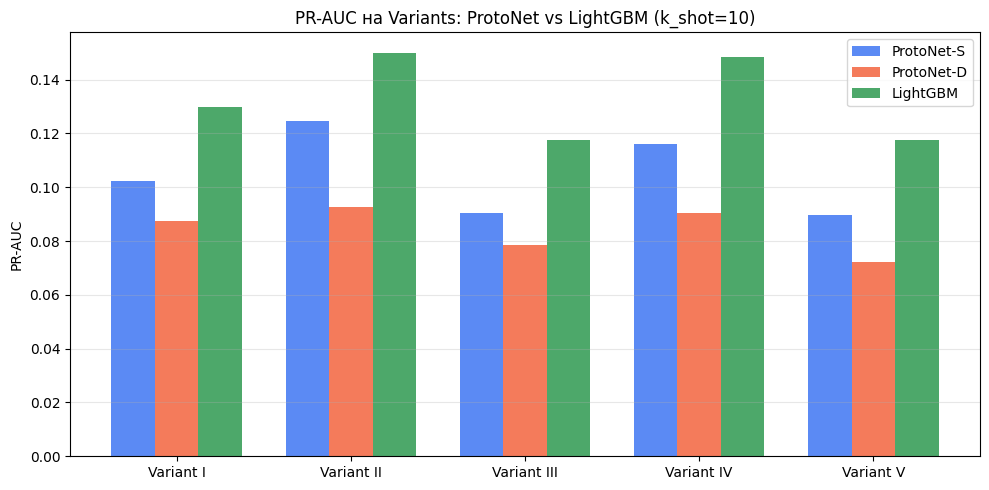

График сохранён: /content/protonet_vs_baseline_prauc.png


In [18]:
# PR-AUC по Variants для трёх моделей
variant_names = ['I', 'II', 'III', 'IV', 'V']

pr_s    = [r['pr_auc'] for r in results_var_s]
pr_d    = [r['pr_auc'] for r in results_var_d]
pr_lgbm = [lgbm_metrics[f'Variant_{n}']['pr_auc'] for n in variant_names]

x = np.arange(len(variant_names))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w,   pr_s,    w, label='ProtoNet-S', color='#5B8AF4')
ax.bar(x,       pr_d,    w, label='ProtoNet-D', color='#F47B5B')
ax.bar(x + w,   pr_lgbm, w, label='LightGBM',  color='#4DA86A')

ax.set_xticks(x)
ax.set_xticklabels([f'Variant {n}' for n in variant_names])
ax.set_ylabel('PR-AUC')
ax.set_title(f'PR-AUC на Variants: ProtoNet vs LightGBM (k_shot={K_SHOT_EVAL})')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/protonet_vs_baseline_prauc.png', dpi=150)
plt.show()
print('График сохранён: /content/protonet_vs_baseline_prauc.png')

## Эксперимент: k_shot = 5 vs 10 (чувствительность к support size)

In [19]:
best_model = model_s  # поменяйте на model_d если MLP-D оказался лучше

kshot_results = []
for k in [5, 10, 20]:
    row = {'k_shot': k}
    for name in ['I', 'II', 'III', 'IV', 'V']:
        res = evaluate_on_variant(
            best_model, X_variants[name], y_variants[name],
            k_shot=k, variant_name=name
        )
        row[f'pr_auc_{name}'] = res['pr_auc']
    row['mean_pr_auc'] = np.mean([row[f'pr_auc_{n}'] for n in ['I','II','III','IV','V']])
    kshot_results.append(row)
    print(f'k_shot={k:>2} | mean PR-AUC = {row["mean_pr_auc"]:.4f}')

kshot_df = pd.DataFrame(kshot_results)
kshot_df.to_csv('/content/kshot_sensitivity.csv', index=False)
print('\nСохранено: /content/kshot_sensitivity.csv')

EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=5, n_query=0
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=5, n_query=0
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=5, n_query=0
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=5, n_query=0
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=5, n_query=0
k_shot= 5 | mean PR-AUC = 0.0969
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=10, n_query=0
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=10, n_query=0
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=10, n_query=0
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=10, n_query=0
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=10, n_query=0
k_shot=10 | mean PR-AUC = 0.1046
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=20, n_query=0
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=20, n_query=0
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=20, n_query=0
EpisodeSampler: класс 0=988,970, класс 1=1

## Сохранение всех артефактов

In [20]:
import json

# Веса моделей
torch.save(model_s.state_dict(), '/content/protonet_mlp_s_final.pt')
torch.save(model_d.state_dict(), '/content/protonet_mlp_d_final.pt')

# Loss-кривые
with open('/content/losses_mlp_s.json', 'w') as f:
    json.dump(losses_s, f)
with open('/content/losses_mlp_d.json', 'w') as f:
    json.dump(losses_d, f)

# Результаты по вариантам
pd.DataFrame(results_var_s).to_csv('/content/results_var_mlp_s.csv', index=False)
pd.DataFrame(results_var_d).to_csv('/content/results_var_mlp_d.csv', index=False)

print('=== Все артефакты сохранены в /content/ ===')
print('Файлы для скачивания:')
artifacts = [
    'protonet_mlp_s_final.pt',
    'protonet_mlp_d_final.pt',
    'results_protonet_vs_baseline.csv',
    'results_protonet_pivot.csv',
    'kshot_sensitivity.csv',
    'protonet_loss_curve.png',
    'protonet_vs_baseline_prauc.png',
]
for a in artifacts:
    print(f'  /content/{a}')

=== Все артефакты сохранены в /content/ ===
Файлы для скачивания:
  /content/protonet_mlp_s_final.pt
  /content/protonet_mlp_d_final.pt
  /content/results_protonet_vs_baseline.csv
  /content/results_protonet_pivot.csv
  /content/kshot_sensitivity.csv
  /content/protonet_loss_curve.png
  /content/protonet_vs_baseline_prauc.png


In [ ]:
# Опционально: скачать все ключевые файлы одной командой
from google.colab import files

for fname in [
    '/content/results_protonet_vs_baseline.csv',
    '/content/results_protonet_pivot.csv',
    '/content/kshot_sensitivity.csv',
    '/content/protonet_loss_curve.png',
    '/content/protonet_vs_baseline_prauc.png',
]:
    files.download(fname)

---
## Что дальше (фаза 3, 18–24 апр)

По расписанию следующий шаг — добавление **MAML / FOMAML** для сравнения методов.  
Ноутбук `04_maml.ipynb` будет содержать:
- Реализацию FOMAML (First-Order MAML) — более простой вариант для начала
- Тот же цикл meta-train / meta-test на тех же данных
- Итоговую таблицу: ProtoNet-S vs ProtoNet-D vs MAML vs LightGBM vs LogReg

**Текущий статус чекпоинта:** если ProtoNet запущен и даёт результаты на Variants,  
фаза 3 (первая половина) закрыта ✓